In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import nibabel as nib
import matplotlib.animation as animation
import matplotlib.colors as mcolors
from pathlib import Path
from model import LightVNet

In [2]:
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"]="1"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
def load_mri_images(base_path):
    modalities = ['flair', 't1', 't1ce', 't2']
    mri_images = {}
    
    for modality in modalities:
        filename = f"BraTS2021_00000_{modality}.nii.gz"
        image_path = os.path.join(base_path, filename)
        
        if not os.path.exists(image_path):
            print(f"No image found for {modality}: {filename}")
            continue
        
        mri_image = sitk.ReadImage(image_path)
        mri_array = sitk.GetArrayFromImage(mri_image)
        
        mri_images[modality] = mri_array
    
    return mri_images

In [4]:
def visualize_mri_slices(mri_images, slice_index=None):
    num_modalities = len(mri_images)
    
    fig, axes = plt.subplots(1, num_modalities, figsize=(20, 5))
    
    if num_modalities == 1:
        axes = [axes]
    
    for i, (modality, image) in enumerate(mri_images.items()):
        if slice_index is None:
            slice_index = image.shape[0] // 2
        
        axes[i].imshow(image[slice_index], cmap='gray')
        axes[i].set_title(f'{modality} - Slice {slice_index}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

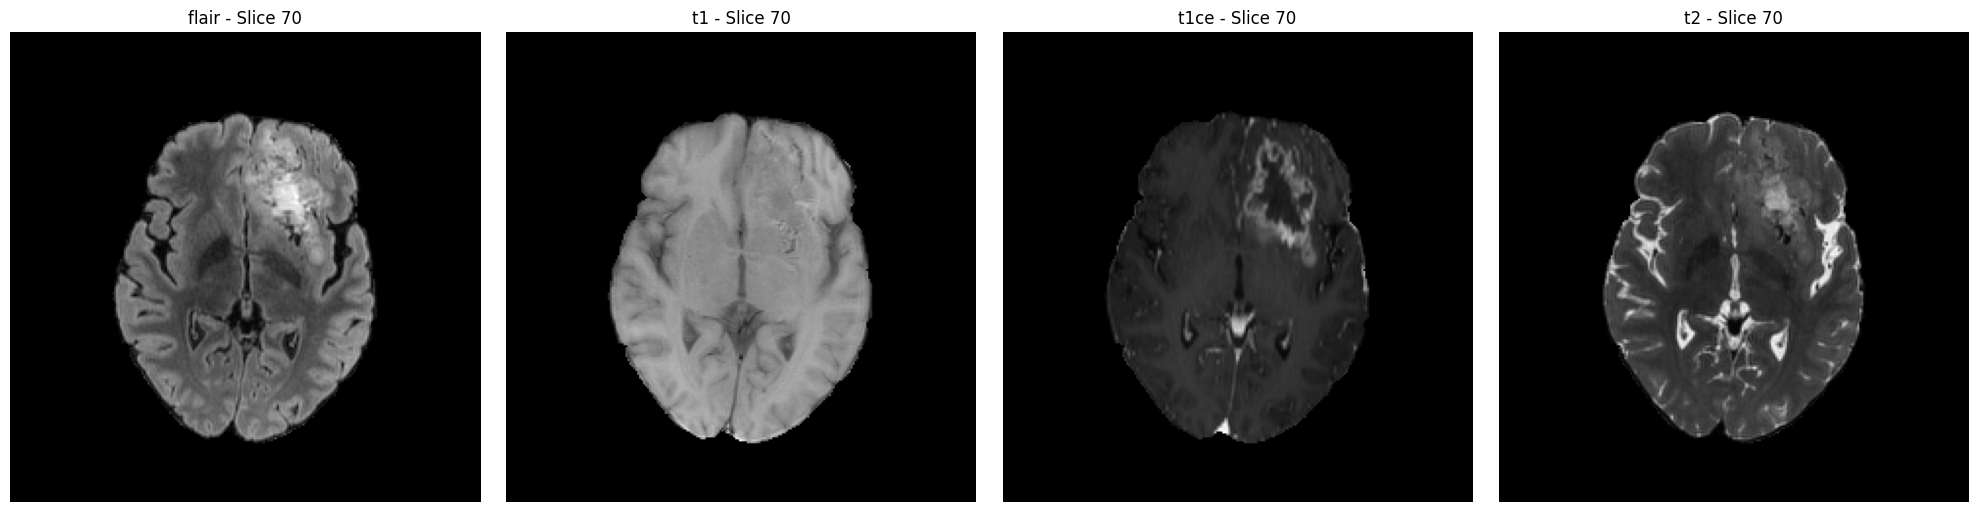

In [5]:
base_path = "/Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet_cleaned/BraTS2021_00000"

mri_images = load_mri_images(base_path)

# Visualize images
if mri_images:
    visualize_mri_slices(mri_images, slice_index=70)
else:
    print("No MRI images could be loaded.")


In [6]:
class BraTSSegmentationVisualizer:
    def __init__(self, directory_path, patient_id):
        """
        Initialize with BraTS 2021 dataset directory and patient ID
        """
        self.directory_path = directory_path
        self.patient_id = patient_id
        base_filename = f'BraTS2021_{patient_id}_'
        
        # Construct full file paths
        self.modality_files = {
            'flair': os.path.join(directory_path, base_filename + 'flair.nii.gz'),
            't1': os.path.join(directory_path, base_filename + 't1.nii.gz'),
            't2': os.path.join(directory_path, base_filename + 't2.nii.gz'),
            't1ce': os.path.join(directory_path, base_filename + 't1ce.nii.gz'),
            'seg': os.path.join(directory_path, base_filename + 'seg.nii.gz')
        }
        
        # Load modalities
        self.modalities = {mod: nib.load(path).get_fdata() 
                           for mod, path in self.modality_files.items()}
        
        # Store header from segmentation file
        self.header = nib.load(self.modality_files['seg']).header
    
    def visualize_segmentation(self, slice_idx=None):
        """Visualize multi-modal MRI and segmentation"""
        if slice_idx is None:
            slice_idx = self.modalities['flair'].shape[2] // 2
        
        plt.figure(figsize=(20, 4))
        modality_names = ['flair', 't1', 't2', 't1ce', 'seg']
        
        for i, modality in enumerate(modality_names, 1):
            plt.subplot(1, 5, i)
            if modality == 'seg':
                plt.imshow(self.modalities[modality][:,:,slice_idx], cmap='jet')
                plt.title('Segmentation')
            else:
                plt.imshow(self.modalities[modality][:,:,slice_idx], cmap='gray')
                plt.title(modality.upper())
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def get_tumor_volumes(self):
        """Calculate tumor volumes"""
        # Get voxel dimensions
        voxel_dims = self.header.get_zooms()
        voxel_volume = np.prod(voxel_dims)
        
        volumes = {
            'whole_tumor': np.sum(self.modalities['seg'] > 0) * voxel_volume,
            'tumor_core': np.sum(np.isin(self.modalities['seg'], [1, 4])) * voxel_volume,
            'enhancing_tumor': np.sum(self.modalities['seg'] == 4) * voxel_volume
        }
        
        return volumes

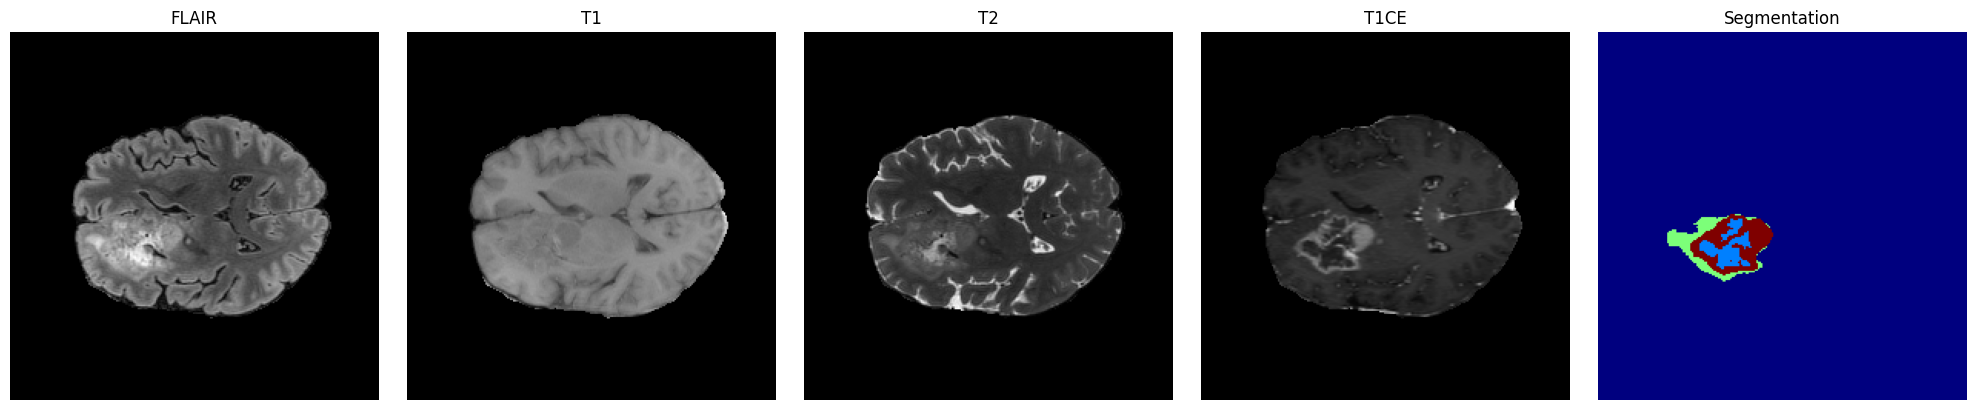

{'whole_tumor': 57305.0, 'tumor_core': 44469.0, 'enhancing_tumor': 32731.0}


In [7]:
patient_id = '00000'
visualizer = BraTSSegmentationVisualizer(base_path, patient_id)
visualizer.visualize_segmentation()
print(visualizer.get_tumor_volumes())


In [8]:
class BraTSSegmentationVisualizer:
    def __init__(self, directory_path, patient_id):
        """
        Initialize with BraTS 2021 dataset directory and patient ID
        """
        self.directory_path = directory_path
        self.patient_id = patient_id
        base_filename = f'BraTS2021_{patient_id}_'
        
        # Construct full file paths
        self.modality_files = {
            'flair': os.path.join(directory_path, base_filename + 'flair.nii.gz'),
            't1': os.path.join(directory_path, base_filename + 't1.nii.gz'),
            't2': os.path.join(directory_path, base_filename + 't2.nii.gz'),
            't1ce': os.path.join(directory_path, base_filename + 't1ce.nii.gz'),
            'seg': os.path.join(directory_path, base_filename + 'seg.nii.gz')
        }
        
        # Load modalities
        self.modalities = {mod: nib.load(path).get_fdata() 
                           for mod, path in self.modality_files.items()}
        
        # Store header from segmentation file (for voxel dims, etc.)
        self.header = nib.load(self.modality_files['seg']).header
        
    def visualize_segmentation(self, slice_idx=None):
        """Visualize multi-modal MRI and segmentation at a given slice index"""
        if slice_idx is None:
            slice_idx = self.modalities['flair'].shape[2] // 2
        
        plt.figure(figsize=(20, 4))
        modality_names = ['flair', 't1', 't2', 't1ce', 'seg']
        
        for i, modality in enumerate(modality_names, 1):
            plt.subplot(1, 5, i)
            slice_data = self.modalities[modality][:, :, slice_idx]
            if modality == 'seg':
                # Use a discrete colormap for segmentation
                seg_cmap = mcolors.ListedColormap(['black', 'red', 'green', 'blue'])
                seg_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 4.5], seg_cmap.N)
                plt.imshow(slice_data, cmap=seg_cmap, norm=seg_norm, origin='lower')
                plt.title('Segmentation')
            else:
                # Normalize using percentiles for better contrast
                vmin, vmax = np.percentile(slice_data, (1, 99))
                plt.imshow(slice_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
                plt.title(modality.upper())
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def get_tumor_volumes(self):
        """Calculate tumor volumes"""
        # Get voxel dimensions
        voxel_dims = self.header.get_zooms()
        voxel_volume = np.prod(voxel_dims)
        
        volumes = {
            'whole_tumor': np.sum(self.modalities['seg'] > 0) * voxel_volume,
            'tumor_core': np.sum(np.isin(self.modalities['seg'], [1, 4])) * voxel_volume,
            'enhancing_tumor': np.sum(self.modalities['seg'] == 4) * voxel_volume
        }
        
        return volumes
    
    def create_segmentation_gif(self, output_file="segmentation.gif", interval=200):
        """
        Create and save an animated GIF showing each axial slice of the MRI and segmentation.
        
        Parameters:
            output_file (str): The filename for the saved GIF.
            interval (int): Delay between frames in milliseconds.
        """
        modality_names = ['flair', 't1', 't2', 't1ce', 'seg']
        num_slices = self.modalities['flair'].shape[2]
        
        # Define a discrete colormap for segmentation
        seg_cmap = mcolors.ListedColormap(['black', 'red', 'green', 'blue'])
        seg_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 4.5], seg_cmap.N)
        
        # Set up the figure and axes
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        ims = []  # List to store the image objects for each modality
        
        # Initialize with the first slice, applying normalization for non-segmentation images
        for ax, modality in zip(axes, modality_names):
            slice_data = self.modalities[modality][:, :, 0]
            if modality == 'seg':
                im = ax.imshow(slice_data, cmap=seg_cmap, norm=seg_norm, animated=True, origin='lower')
            else:
                vmin, vmax = np.percentile(slice_data, (1, 99))
                im = ax.imshow(slice_data, cmap='gray', animated=True, origin='lower', vmin=vmin, vmax=vmax)
            ax.set_title(modality.upper())
            ax.axis('off')
            ims.append(im)
        
        def update(frame):
            """Update each subplot for the current slice (frame)"""
            for im, modality in zip(ims, modality_names):
                slice_data = self.modalities[modality][:, :, frame]
                if modality != 'seg':
                    vmin, vmax = np.percentile(slice_data, (1, 99))
                    im.set_data(slice_data)
                    im.set_clim(vmin, vmax)
                else:
                    im.set_data(slice_data)
                    # The norm for segmentation is fixed, so no need to update it
            fig.suptitle(f"Slice {frame+1} / {num_slices}")
            return ims
        
        # Create the animation using FuncAnimation
        ani = animation.FuncAnimation(fig, update, frames=num_slices, interval=interval, blit=False)
        
        # Save the animation as a GIF using PillowWriter
        ani.save(output_file, writer='pillow')
        plt.close(fig)
        print(f"Segmentation animation saved as {output_file}")

In [9]:
# visualizer = BraTSSegmentationVisualizer(directory_path=base_path, patient_id="00000")
# visualizer.create_segmentation_gif(output_file="my_segmentation.gif", interval=200)

In [10]:
image = nib.load("/Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet_cleaned/BraTS2021_00000/BraTS2021_00000_seg.nii.gz")

print( image.shape )

(240, 240, 155)


In [11]:
class BraTSDataset(Dataset):
    def __init__(self, data_dir, patch_size=64):
        self.data_dir = Path(data_dir)
        self.patch_size = patch_size
        # Each patient folder is expected under the given directory.
        self.cases = list(self.data_dir.glob("*"))
        print(f"Found {len(self.cases)} cases in {data_dir}")
        
    def __len__(self):
        # Using a multiple (e.g., 4 patches per case) for sampling.
        return len(self.cases) * 4
        
    def __getitem__(self, idx):
        case_idx = idx // 4
        case_path = self.cases[case_idx]
        
        # Use glob patterns to find the files.
        flair  = self.load_nifti(self.get_file(case_path, "*flair.nii.gz"))
        t1     = self.load_nifti(self.get_file(case_path, "*t1.nii.gz"))
        t1ce   = self.load_nifti(self.get_file(case_path, "*t1ce.nii.gz"))
        t2     = self.load_nifti(self.get_file(case_path, "*t2.nii.gz"))
        mask   = self.load_nifti(self.get_file(case_path, "*seg.nii.gz"))
        
        # Normalize the images (skip normalizing the segmentation mask)
        flair  = self.normalize(flair)
        t1     = self.normalize(t1)
        t1ce   = self.normalize(t1ce)
        t2     = self.normalize(t2)
        
        # Stack modalities (channels first)
        image = np.stack([flair, t1, t1ce, t2])
        
        # Extract a random patch from the image and mask.
        patch, mask_patch = self.extract_patch(image, mask)
        
        return torch.FloatTensor(patch), torch.LongTensor(mask_patch)
    
    def normalize(self, img):
        # Only consider non-zero voxels when computing mean and std.
        mask = img > 0
        mean = img[mask].mean()
        std = img[mask].std()
        return (img - mean) / (std + 1e-8)
    
    def load_nifti(self, path):
        try:
            # Load the NIfTI image and return its data as a NumPy array.
            return nib.load(str(path)).get_fdata()
        except Exception as e:
            print(f"Error loading {path}: {e}")
            raise
    
    def get_file(self, case_path, pattern):
        """
        Searches for a file matching the given pattern within the case_path.
        For example, pattern="*flair.nii.gz" will match "BraTS2021_00000_flair.nii.gz".
        """
        files = list(case_path.glob(pattern))
        if not files:
            raise FileNotFoundError(f"No file found for pattern {pattern} in {case_path}")
        return files[0]
    
    def extract_patch(self, image, mask):
        """
        Extracts a random cubic patch from the image and corresponding region from the mask.
        Uses the nonzero region in the first channel of the image (assumed to be FLAIR)
        to determine approximate brain bounds.
        """
        # Find non-zero indices in the FLAIR channel.
        brain_region = np.where(image[0] > 0)
        
        # Compute approximate bounds using the 5th and 95th percentiles.
        x_bounds = np.percentile(brain_region[0], [5, 95])
        y_bounds = np.percentile(brain_region[1], [5, 95])
        z_bounds = np.percentile(brain_region[2], [5, 95])
        
        p = self.patch_size // 2
        
        # Randomly choose the center of the patch within the bounds.
        x = np.random.randint(max(p, int(x_bounds[0])), min(image.shape[1] - p, int(x_bounds[1])))
        y = np.random.randint(max(p, int(y_bounds[0])), min(image.shape[2] - p, int(y_bounds[1])))
        z = np.random.randint(max(p, int(z_bounds[0])), min(image.shape[3] - p, int(z_bounds[1])))
        
        # Extract the patch from all modalities and the corresponding mask patch.
        image_patch = image[:, x-p:x+p, y-p:y+p, z-p:z+p]
        mask_patch  = mask[x-p:x+p, y-p:y+p, z-p:z+p]
        
        return image_patch, mask_patch

In [12]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, predictions, targets):
        predictions = torch.softmax(predictions, dim=1)
        
        predictions = predictions.view(-1)
        targets = targets.view(-1)
        
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)
        
        return 1 - dice


In [13]:
def train_model(model, train_loader, val_loader, num_epochs=5):
    device = torch.device("mps")
    model = model.to(device)
    
    criterion = DiceLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output, target).item()
        
        print(f'Epoch {epoch}')
        print(f'Training Loss: {train_loss/len(train_loader):.4f}')
        print(f'Validation Loss: {val_loss/len(val_loader):.4f}')
        print('------------------------')

In [14]:
# Set device
num_workers = 0 
device = torch.device("mps")  # M1 Mac
print(f"Using device: {device}")

# Paths
train_dir = Path("/Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet_cleaned")
val_dir = Path("/Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_ValidationSet_cleaned")

train_dataset = BraTSDataset(train_dir, patch_size=64)
val_dataset = BraTSDataset(val_dir, patch_size=64)

train_loader = DataLoader(
    train_dataset, 
    batch_size=2, 
    shuffle=True, 
    num_workers=num_workers,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=2, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=True
)

model = LightVNet(in_channels=4, num_classes=4)
train_model(model, train_loader, val_loader)

Using device: mps
Found 1252 cases in /Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_TrainingSet_cleaned
Found 220 cases in /Users/Viku/Datasets/Medical/BraTs-2021/RSNA-ASNR-MICCAI-BraTS-2021/BraTS2021_ValidationSet_cleaned


NotImplementedError: The operator 'aten::max_pool3d_with_indices' is not currently implemented for the MPS device. If you want this op to be considered for addition please comment on https://github.com/pytorch/pytorch/issues/141287 and mention use-case, that resulted in missing op as well as commit hash 2236df1770800ffea5697b11b0bb0d910b2e59e1. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.